#Solving LMG model in continuous monitored scheme: using quantum trajectory


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as la
from math import *
from tqdm import tqdm

In [2]:
def energy(h,mz,phi):
    E = -(1-mz**2) * (np.cos(phi))**2 - 2*h*mz
    return E
    
def maps(mx_0,my_0,mz_0,h,g,dt,deps):
    
    dmx = (2*h*my_0  - 0.5*g*mx_0) *dt - np.sqrt(g)*deps * mz_0 *mx_0
    dmy = (2*mx_0 *mz_0 - 2*h*mx_0 - 0.5*g *my_0) *dt  -  np.sqrt(g)*deps * mz_0 * my_0
    dmz = (-2*mx_0 *my_0 ) *dt + np.sqrt(g)*deps * (1 - mz_0**2)
    mx = mx_0 + dmx
    #mx= np.clip(mx,-1.0,1.0)
    my = my_0 + dmy
    #my= np.clip(my,-1.0,1.0)
    mz = mz_0 + dmz
    #mz= np.clip(mz,-1.0,1.0)
    norm = np.sqrt(mx**2 + my**2 + mz**2) # just to make every magnetization in range(-1,1)
    #M = np.array([mx/norm , my/norm , mz/norm])
    
    return mx/norm , my/norm , mz/norm
    
def twod_phase(mz,phi,h,g,dt,deps):
    dmz = -2*(1-mz**2)*np.sin(phi) * np.cos(phi) * dt + np.sqrt(g) *(1-mz**2)*deps
    dphi = 2*(-h + mz*(np.cos(phi))**2)*dt
    mz = mz + dmz
    phi = phi + dphi
    phi =np.arctan2(np.sin(phi),np.cos(phi))
    
    return mz,phi



    

In [3]:

print(maps(1,0,0,0.2,0.1,0.1,0.05))
print(twod_phase(0,0,0.2,0.1,0.1,0.05))


(0.999066987554222, -0.040163496987104405, 0.015876016159570034)
(0.0158113883008419, -0.04000000000000001)


In [6]:
h= 0.2
g= 0.01
dt= 0.01
R= 300 # number of realizations for deps
#deps= np.linspace(-np.sqrt(dt),np.sqrt(dt),R) # different noise realizations
T= 200
steps = int(T/dt)
PHI = np.zeros((R,steps))
M_z= np.zeros((R,steps))
#M_y= np.zeros((R,steps))
#M_x= np.zeros((R,steps))
t= np.zeros(steps)
for i in range(steps):
    t[i]=i*dt
# magnetization for each realization of deps and time is stored

for r in range(R):
  
    mx =1
    my =0
    mz =0
    #phi=0
   # M_x[r,0] = mx
   # M_y[r,0] = my
    M_z[r,0] = mz
    #PHI[r,0] = phi
    
    for j in range(1,steps):
        deps = np.sqrt(dt) * np.random.normal(0,1) # different realization of noise with mean 0 and std 1
        mx,my,mz = maps(mx,my,mz,h,g,dt,deps)
       # M_x[r,j] = mx
       # M_y[r,j] = my
        M_z[r,j] = mz
        '''
        mz,phi = twod_phase(mz,phi,h,g,dt,deps[r])
        M_z[r,j] = mz
        PHI[r,j] = phi
        '''  
# Now do the ensemble average or sum over r , for z magnetization
Ens_av_Mz = np.mean(M_z,axis=0)#np.zeros(steps) # ensemble averaged magnetization
Mz_inf = np.sum(Ens_av_Mz)/steps
'''
for i in range(steps):
    sum=0
    for j in range(R):
        sum = sum + M_z[j,i]
    Ens_av_Mz[i] = sum/R
   
Mz_inf = np.sum(Ens_av_Mz)/steps
'''


'\nfor i in range(steps):\n    sum=0\n    for j in range(R):\n        sum = sum + M_z[j,i]\n    Ens_av_Mz[i] = sum/R\n   \nMz_inf = np.sum(Ens_av_Mz)/steps\n'

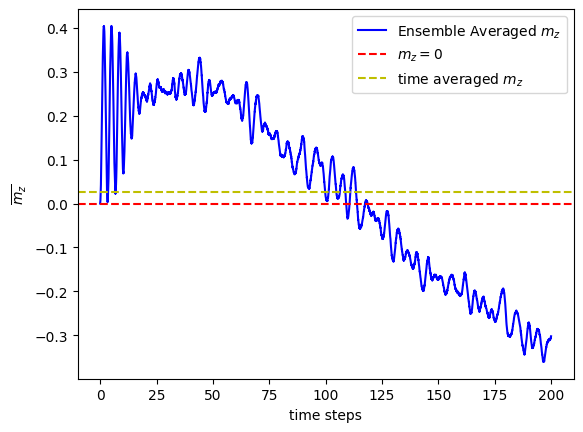

In [7]:
plt.plot(t,Ens_av_Mz,color='b',label='Ensemble Averaged $m_z$')
plt.xlabel("time steps")
plt.ylabel("$\overline{m_z}$")

plt.axhline(y=0,color="r",linestyle="--",label="$m_z=0$")
plt.axhline(y=Mz_inf,color='y',linestyle="--",label="time averaged $m_z$")
plt.legend()
plt.show()

In [8]:
# Finding the energy in mz and phi phase space

Text(0, 0.5, '$m_z$')

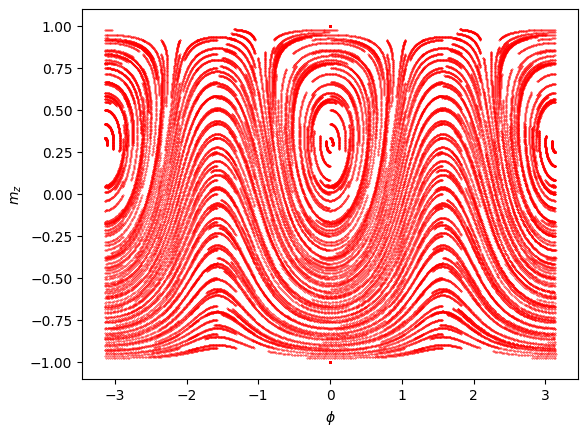

In [8]:
steps=100
g=0.0
h=0.3
dt=0.01
deps= np.random.normal(0,1) * np.sqrt(dt)
n=25
mz_ini=np.linspace(-1.0,1.0,n)
phi_ini=np.linspace(-np.pi,np.pi,n)

plt.figure()

for i1 in range(n): 
    for i2 in range(n):
        mx = np.sqrt(1-mz_ini[i1]**2)* np.cos(phi_ini[i2])
        my = np.sqrt(1-mz_ini[i1]**2)* np.sin(phi_ini[i2])
        mz = mz_ini[i1]
        MZ = np.zeros(steps)
        PHI = np.zeros(steps)
        E = np.zeros(steps)
        for j in range(steps):
            deps=  np.random.normal(0,1) * np.sqrt(dt) # different noise realizations
            mx,my,mz = maps(mx,my,mz,h,g,dt,deps)

            
            PHI[j]= np.arctan2(my,mx)
            MZ[j]= mz
            E[j] = energy(h,MZ[j],PHI[j])
           

        
        sc= plt.scatter(PHI,MZ,s=0.1,color='r') # each point(phi,mz) is colored by the energy
#plt.colorbar()
plt.xlabel("$\phi$")
plt.ylabel("$m_z$")
        
            
            
        
        
        

            
            
            

    
    


In [9]:
# Finding the phase transition plot

In [10]:
n1 =15
n2= 16

h= np.linspace(0.0,2.0,n1)
gamma = np.linspace(0.0,2.0,n2)
p= np.zeros((n1,n2))  # for the order parameter
dt= 0.01
R= 50 # number of realizations for deps

T= 100
steps = int(T/dt)

for k1 in range(n1): # for h
    
    for k2 in range(n2): # for gamma
        M_z= np.zeros((R,steps))
       # M_y= np.zeros((R,steps))
       # M_x= np.zeros((R,steps))
        #t=[i for i in range(0,steps)]
        # magnetization for each realization of deps and time is stored
        #with tqdm(total=R) as pbar:
        for r in range(R):
            mx =1
            my =0
            mz =0
           # M_x[r,0] = mx
           # M_y[r,0] = my
            M_z[r,0] = mz
            for j in range(1,steps):
                deps=  np.random.normal(0,1) * np.sqrt(dt) # different noise realizations
                mx,my,mz = maps(mx,my,mz,h[k1],gamma[k2],dt,deps)       
              #  M_x[r,j] = mx
              #  M_y[r,j] = my
                M_z[r,j] = mz
      
    
        # Now do the ensemble average or sum over r , for z magnetization
        Ens_av_Mz = np.mean(M_z,axis=0)     # np.zeros(steps) # ensemble averaged magnetization
        p1 = np.zeros(steps)
        for i in range(steps):
            p1[i] = 0.5 *(1 + Ens_av_Mz[i])
                          
        p[k1,k2]= np.sum(p1)/steps
                          

        '''
        for i in range(steps):
            sum=0
            for j in range(R):
                sum = sum + M_z[j,i]
            Ens_av_Mz[i] = sum/R
            p1[i] = 0.5 *(1 + Ens_av_Mz[i])
        '''
        
    #pbar.update(1)
#print(h.shape)
#print(gamma.shape)
#print(p.shape)
 

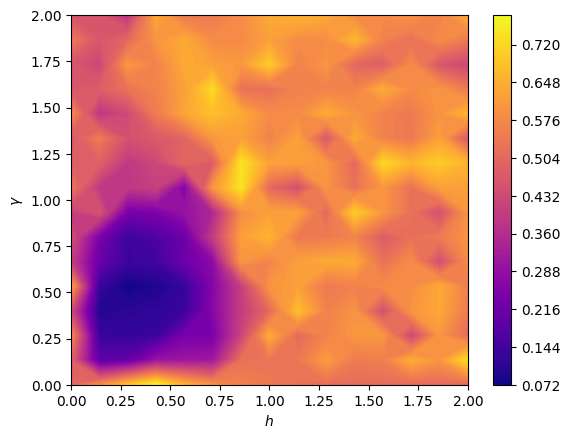

In [11]:
[X,Y]= np.meshgrid(h,gamma)
Z=p.T
plt.contourf(X,Y,Z,levels=100,cmap="plasma")
plt.xlabel("$h$")
plt.ylabel("$\gamma$")
plt.colorbar()